In [15]:
#1.import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [49]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')
test_data.info()
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1000 non-null   int64  
 1   battery_power  1000 non-null   int64  
 2   blue           1000 non-null   int64  
 3   clock_speed    1000 non-null   float64
 4   dual_sim       1000 non-null   int64  
 5   fc             1000 non-null   int64  
 6   four_g         1000 non-null   int64  
 7   int_memory     1000 non-null   int64  
 8   m_dep          1000 non-null   float64
 9   mobile_wt      1000 non-null   int64  
 10  n_cores        1000 non-null   int64  
 11  pc             1000 non-null   int64  
 12  px_height      1000 non-null   int64  
 13  px_width       1000 non-null   int64  
 14  ram            1000 non-null   int64  
 15  sc_h           1000 non-null   int64  
 16  sc_w           1000 non-null   int64  
 17  talk_time      1000 non-null   int64  
 18  three_g  

In [50]:
#data.isnull().sum()

In [51]:
#print(train_data['price_range'].value_counts)

In [52]:
train_data = train_data[train_data['price_range'].isin([0,3])]

In [53]:
train_data['price_range'] = train_data['price_range'].map({0:0,3:1})
print(train_data['price_range'].value_counts())

price_range
1    500
0    500
Name: count, dtype: int64


In [54]:
X = train_data.drop('price_range', axis=1)  # 'price_range' is the target
y = train_data['price_range']
y

6       1
7       0
8       0
9       0
10      1
       ..
1994    1
1995    0
1997    1
1998    0
1999    1
Name: price_range, Length: 1000, dtype: int64

In [58]:
X_train, X_test, y_train, y_test = train_test_split(train_data, y, test_size=0.2, random_state=42)

In [59]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
# Initialize and train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [61]:
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.98

Confusion Matrix:
 [[ 89   2]
 [  2 107]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        91
           1       0.98      0.98      0.98       109

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



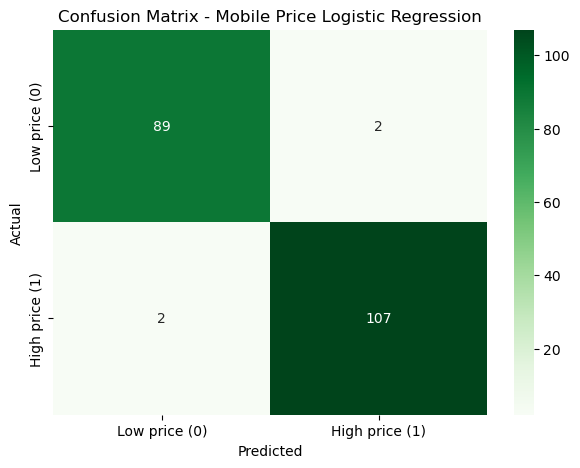

In [73]:
#VISUALIZATION😶😶
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',xticklabels=['Low price (0)', 'High price (1)'],yticklabels=['Low price (0)', 'High price (1)'])
plt.title('Confusion Matrix - Mobile Price Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
